# Black Friday Purchase Prediction — Regression

## Machine Learning Capstone Project

**Dataset:** Black Friday Dataset  
**Target Variable:** Purchase  
**Problem Type:** Regression

This notebook implements an end-to-end regression pipeline including:
- Exploratory Data Analysis
- Data Cleaning
- Feature Engineering
- Data Preprocessing
- Training and Comparison of 10 Regression Algorithms
- Hyperparameter Tuning
- Model Evaluation
- Cross-Validation
- Regression Visualizations

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")


In [6]:
from IPython.core import getipython
!git clone https://github.com/snehitha-araveti/ML-Capstone-Project-2026.git

Cloning into 'ML-Capstone-Project-2026'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 15 (delta 0), reused 2 (delta 0), pack-reused 11 (from 1)
Receiving objects: 100% (15/15), 49.52 MiB | 26.30 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [7]:
df = pd.read_csv("/content/ML-Capstone-Project-2026/data/Black Friday Dataset.csv")

In [ ]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [8]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (550068, 12)

Column Names:
['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase']

Data Types:
User_ID                         int64
Product_ID                     object
Gender                         object
Age                            object
Occupation                      int64
City_Category                  object
Stay_In_Current_City_Years     object
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [10]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,173638


In [11]:
df.duplicated().sum()

np.int64(0)

## Target Variable Distribution

The target variable for this regression problem is `Purchase`.

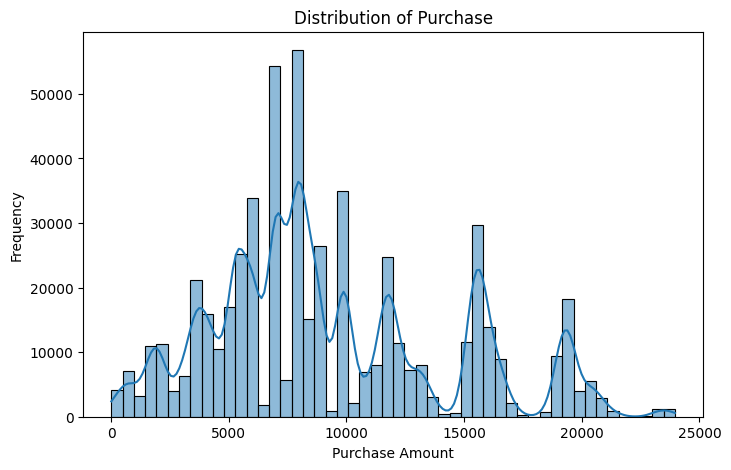

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Purchase"], bins=50, kde=True)
plt.title("Distribution of Purchase")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

## Distribution of Features

The distributions of all predictor variables

In [13]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include="object").columns.tolist()
numerical_features.remove("Purchase")
print("Numerical Features:")
print(numerical_features)
print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['User_ID', 'Occupation', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3']

Categorical Features:
['Product_ID', 'Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years']


## Numerical feature distributions

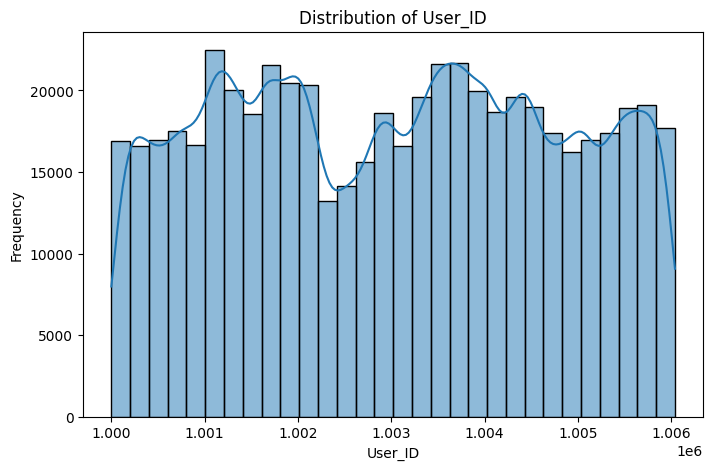

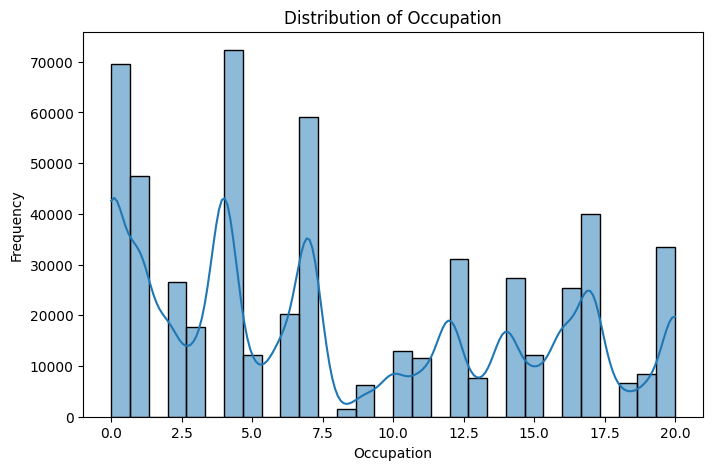

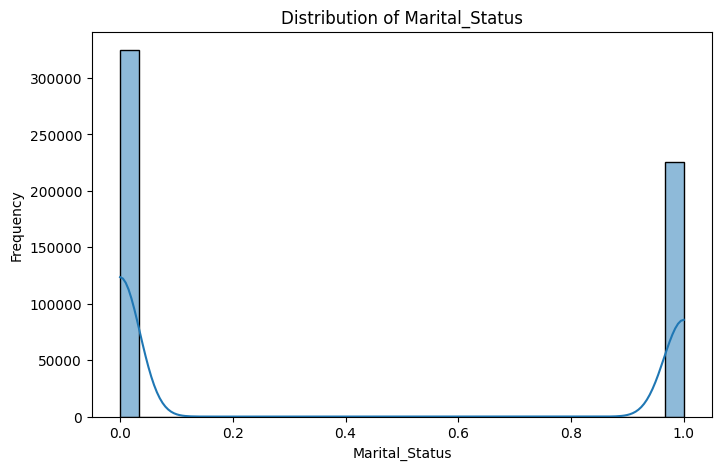

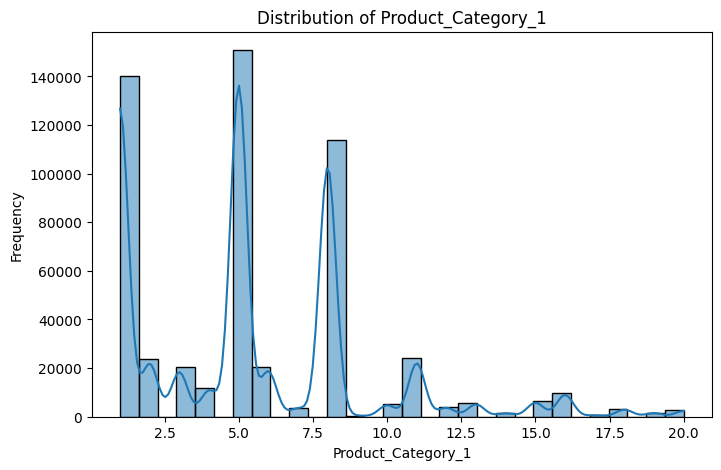

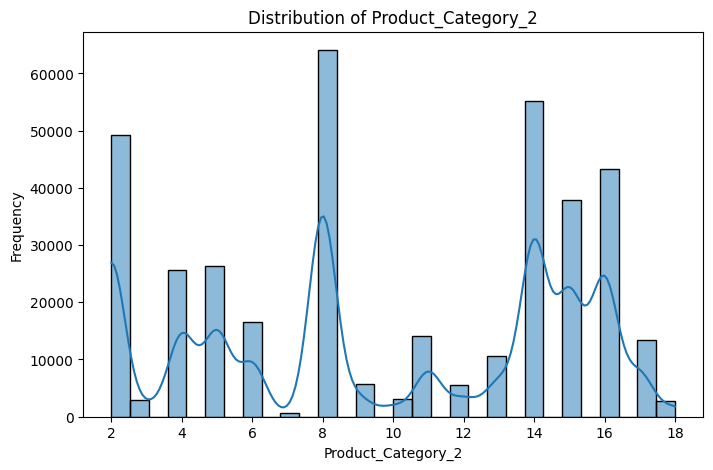

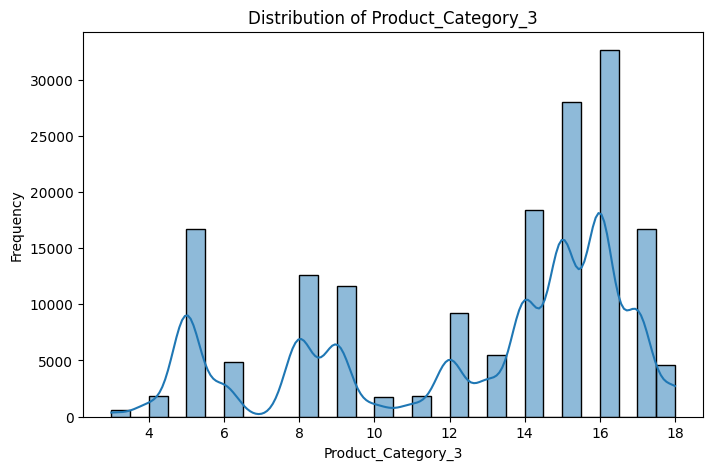

In [14]:
for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature], bins=30, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

## Categorical feature distributions

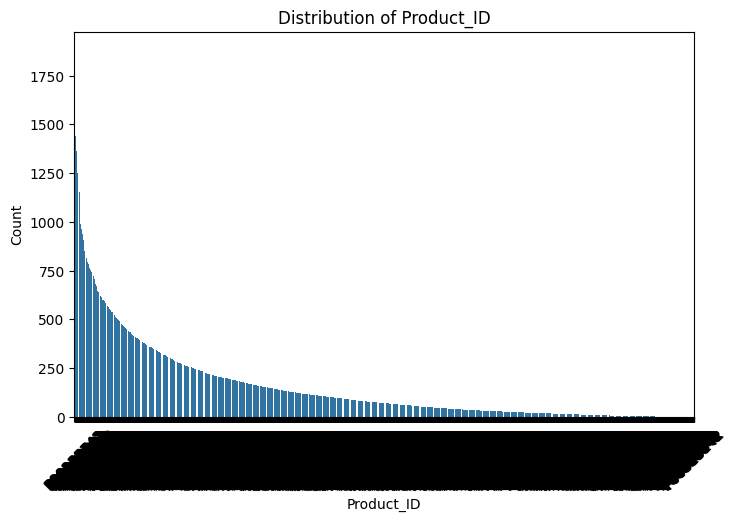

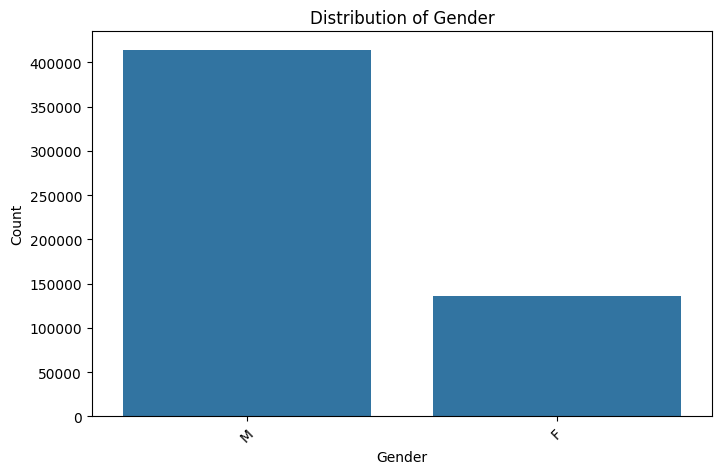

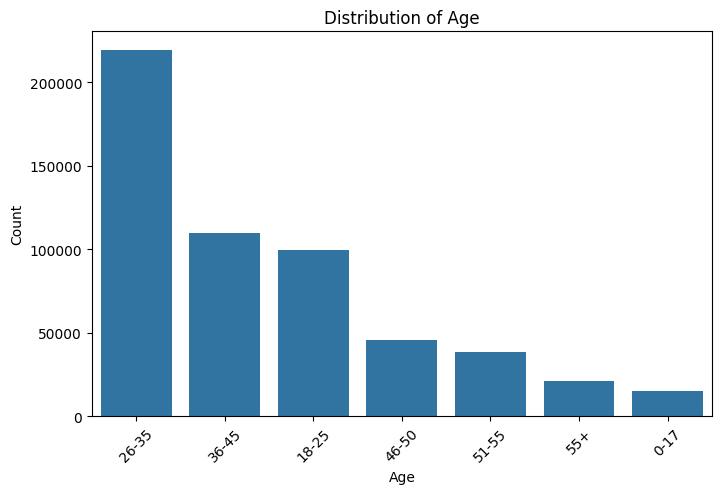

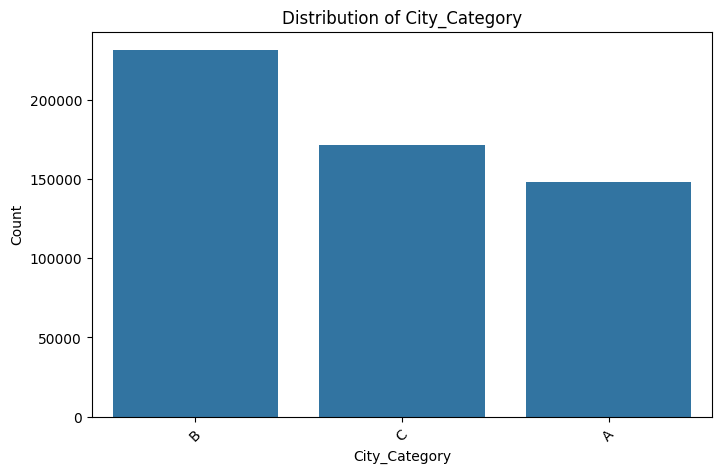

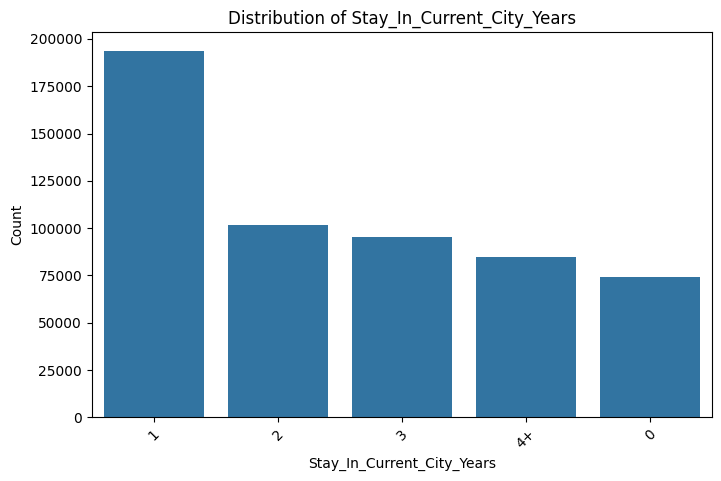

In [15]:
for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df,x=feature,order=df[feature].value_counts().index)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

## Correlation Heatmap

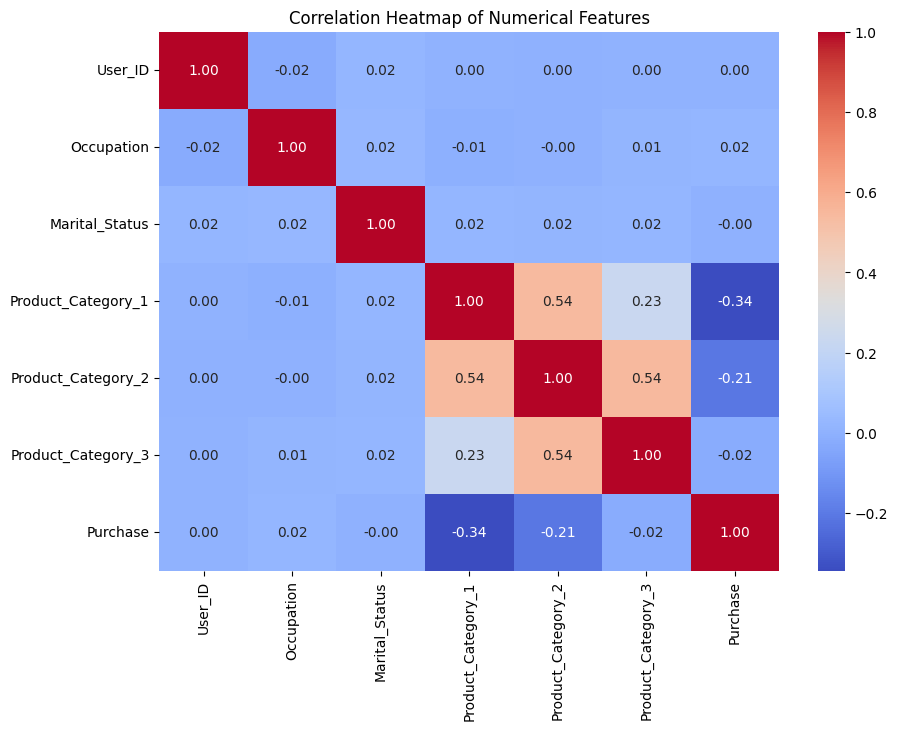

In [16]:
plt.figure(figsize=(10, 7))
correlation_matrix = df[numerical_features + ["Purchase"]].corr()
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Feature-Target Relationship: Product Category 1

A scatter plot is used to examine the relationship between Product_Category_1 and the target variable Purchase.

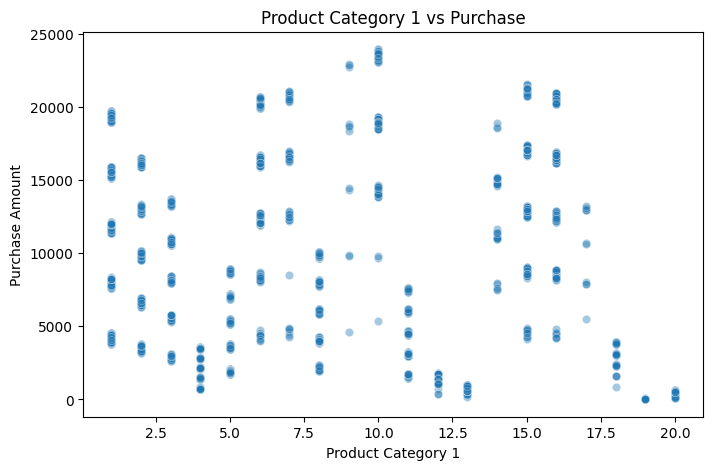

In [17]:
plot_sample = df.sample(10000, random_state=42)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_sample,x="Product_Category_1",y="Purchase",alpha=0.4)
plt.title("Product Category 1 vs Purchase")
plt.xlabel("Product Category 1")
plt.ylabel("Purchase Amount")
plt.show()

## Feature-Target Relationship: Occupation

A second scatter plot is used to examine the relationship between Occupation and Purchase.

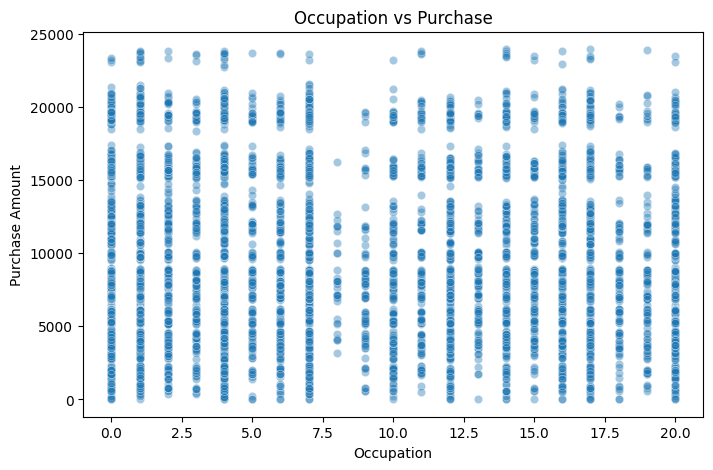

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_sample,x="Occupation",y="Purchase",alpha=0.4)
plt.title("Occupation vs Purchase")
plt.xlabel("Occupation")
plt.ylabel("Purchase Amount")
plt.show()

### Section B
## Data Cleaning

The dataset contains missing values in `Product_Category_2` and
`Product_Category_3`. Since these are numerical product-category variables,
their missing values are replaced using the median of each column.

The median is used because it is less sensitive to extreme values than the
mean and allows us to retain the available observations.

In [19]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,173638


In [20]:
df["Product_Category_2"] = df["Product_Category_2"].fillna(df["Product_Category_2"].median())
df["Product_Category_3"] = df["Product_Category_3"].fillna(df["Product_Category_3"].median())

In [21]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,0


In [22]:
df.duplicated().sum()

np.int64(0)

## Outlier Detection

Outliers are checked using the Interquartile Range (IQR) method. The IQmethod identifies observations lying below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR.

In [23]:
Q1 = df["Purchase"].quantile(0.25)
Q3 = df["Purchase"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["Purchase"] < lower_bound) |(df["Purchase"] > upper_bound)]
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

Lower bound: -3523.5
Upper bound: 21400.5
Number of outliers: 2677


In [24]:
df["Purchase"].describe()

,Purchase
count,550068.000000
mean,9263.968713
std,5023.065394
min,12.000000
25%,5823.000000
50%,8047.000000
75%,12054.000000
max,23961.000000


In [25]:
df["Purchase"] = df["Purchase"].clip(lower=lower_bound,upper=upper_bound)
outliers1 = df[(df["Purchase"] < lower_bound) |(df["Purchase"] > upper_bound)]
print("Number of outliers:", len(outliers1))

Number of outliers: 0


## Feature Engineering

An `Age_Midpoint` feature is created from the existing age-group variable.Each age range is represented by its midpoint.

This provides an ordered numerical representation of the customer's age group,which may help regression models capture an approximately monotonic
relationship between age and purchase amount.

In [26]:
age_midpoints = {
    "0-17": 8.5,
    "18-25": 21.5,
    "26-35": 30.5,
    "36-45": 40.5,
    "46-50": 48,
    "51-55": 53,
    "55+": 60
}

df["Age_Midpoint"] = df["Age"].map(age_midpoints)
df[["Age", "Age_Midpoint"]].head()

,Age,Age_Midpoint
0,0-17,8.5
1,0-17,8.5
2,0-17,8.5
3,0-17,8.5
4,55+,60.0


## Encoding, Scaling & Splitting

Purchase is continuous, so we cannot directly do stratify=y.so create quantile bins of Purchase and use those bins only for stratification

In [27]:
categorical_columns = ["Gender","Age","City_Category","Stay_In_Current_City_Years"]
df = pd.get_dummies(df,columns=categorical_columns,drop_first=True,dtype=int)

In [28]:
# removing user id and product id
df = df.drop(columns=["User_ID", "Product_ID"])

In [29]:
df.head()

,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,Age_Midpoint,Gender_M,Age_18-25,Age_26-35,Age_36-45,Age_46-50,Age_51-55,Age_55+,City_Category_B,City_Category_C,Stay_In_Current_City_Years_1,Stay_In_Current_City_Years_2,Stay_In_Current_City_Years_3,Stay_In_Current_City_Years_4+
0,10,0,3,9.0,14.0,8370.0,8.5,0,0,0,0,0,0,0,0,0,0,1,0,0
1,10,0,1,6.0,14.0,15200.0,8.5,0,0,0,0,0,0,0,0,0,0,1,0,0
2,10,0,12,9.0,14.0,1422.0,8.5,0,0,0,0,0,0,0,0,0,0,1,0,0
3,10,0,12,14.0,14.0,1057.0,8.5,0,0,0,0,0,0,0,0,0,0,1,0,0
4,16,0,8,9.0,14.0,7969.0,60.0,1,0,0,0,0,0,1,0,1,0,0,0,1


In [30]:
X = df.drop(columns="Purchase")
Y = df["Purchase"]

print("Features shape:", X.shape)
print("Target shape:", Y.shape)

Features shape: (550068, 19)
Target shape: (550068,)


In [31]:
y_bins = pd.qcut(
    Y,
    q=10,
    labels=False,
    duplicates="drop"
)

print(y_bins.value_counts().sort_index())

Purchase
0    55008
1    55049
2    55032
3    54985
4    55068
5    54985
6    54924
7    55046
8    54970
9    55001
Name: count, dtype: int64


## Train Test Split

In [32]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=y_bins
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (440054, 19)
Testing set: (110014, 19)


## Scaling
Standardization is applied to the feature variables so that numerical features are placed on a comparable scale. The scaler is fitted only on the training set and then used to transform both the training and testing sets.

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled training set:", X_train_scaled.shape)
print("Scaled testing set:", X_test_scaled.shape)

Scaled training set: (440054, 19)
Scaled testing set: (110014, 19)
